In [1]:
import polars as pl 
import seaborn as sns 
import matplotlib.pyplot as plt 
from dbconfig import engine 
print('Environment ready!')

Environment ready!


In [2]:
base_table = pl.read_database(
query = """
with match_stats as (

select season, team,
count(distinct id) as matches_played,
sum(is_win) as wins 
from (

select team1 as team,
id, season,
case when winner = team1 then 1 else 0 end as is_win
from matches 

union all 

select team2 as team,
id, season,
case when winner = team2 then 1 else 0 end as is_win
from matches ) as stacked

group by season, team),

delivery_stats as (

select
batting_team as team,
season,
count(*) as balls_faced,
count(*) filter(where total_runs = 0) as dot_balls,
count(*) filter(where batsman_runs in (4,6)) as boundaries,
sum(total_runs) as runs_scored
from ipl_master_view
where inning in (1,2)
group by team, season)

select m.team,
m.season,
m.matches_played,
round(100.00 * m.wins::numeric / m.matches_played, 2) as win_pct,
round(100.00 * d.dot_balls::numeric / d.balls_faced, 2) as dot_ball_pct,
round(100.00 * d.boundaries::numeric / d.balls_faced, 2) as boundary_pct,
round(runs_scored::numeric / d.balls_faced * 6.00, 2) as run_rate
from match_stats m 
join delivery_stats d on m.team = d.team and m.season = d.season
order by m.team, m.season;""",
connection = engine)

In [29]:
base_table.head(5)

team,season,matches_played,win_pct,dot_ball_pct,boundary_pct,run_rate
str,str,i64,"decimal[38,2]","decimal[38,2]","decimal[38,2]","decimal[38,2]"
"""Chennai Super Kings""","""2007/08""",16,56.25,36.18,17.61,8.07
"""Chennai Super Kings""","""2009""",14,57.14,34.41,15.51,7.83
"""Chennai Super Kings""","""2009/10""",16,56.25,33.50,15.88,8.00
"""Chennai Super Kings""","""2011""",16,68.75,32.61,15.15,7.89
"""Chennai Super Kings""","""2012""",18,55.56,34.49,14.89,7.78


In [30]:
base_table.sort(pl.col('dot_ball_pct'), descending = True).head(5)

team,season,matches_played,win_pct,dot_ball_pct,boundary_pct,run_rate
str,str,i64,"decimal[38,2]","decimal[38,2]","decimal[38,2]","decimal[38,2]"
"""Pune Warriors""","""2011""",14,28.57,42.14,14.02,6.98
"""Rajasthan Royals""","""2009""",13,46.15,41.80,12.44,6.56
"""Royal Challengers Bengaluru""","""2014""",14,35.71,40.07,15.51,7.58
"""Pune Warriors""","""2013""",16,25.00,40.01,13.70,6.99
"""Kolkata Knight Riders""","""2013""",16,37.50,39.89,14.51,7.15


In [31]:
base_table.sort(pl.col('boundary_pct'), descending = True).head(5)

team,season,matches_played,win_pct,dot_ball_pct,boundary_pct,run_rate
str,str,i64,"decimal[38,2]","decimal[38,2]","decimal[38,2]","decimal[38,2]"
"""Kolkata Knight Riders""","""2024""",14,78.57,31.05,23.78,10.04
"""Delhi Capitals""","""2024""",14,50.00,33.39,22.18,9.41
"""Royal Challengers Bengaluru""","""2024""",15,46.67,29.43,21.67,9.67
"""Mumbai Indians""","""2023""",16,56.25,32.42,21.04,9.18
"""Mumbai Indians""","""2024""",14,28.57,33.99,20.64,9.14


In [3]:
plot_table = base_table.with_columns(
        pl.col("win_pct").cast(pl.Float64),
        pl.col("dot_ball_pct").cast(pl.Float64),
        pl.col("boundary_pct").cast(pl.Float64),
        pl.col("run_rate").cast(pl.Float64))

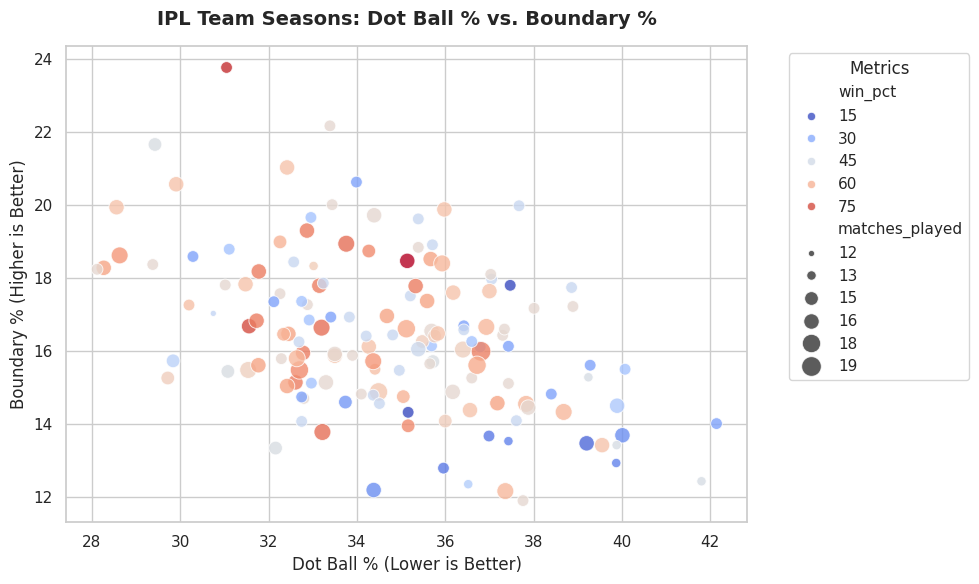

In [35]:
# 1. Set the canvas size (width=10, height=6 inches)
plt.figure(figsize=(10, 6))

# 2. Set the style to make it look premiumsns
sns.set_theme(style="whitegrid")

# 3. Create the scatter plot
sns.scatterplot(
    data=plot_table,
    x="dot_ball_pct",
    y="boundary_pct",
    hue="win_pct",         # Color the dots by win percentage
    palette="coolwarm",    # Cool (blue) for low win %, Warm (red) for high win %
    size="matches_played", # Larger dots for seasons with more games (reduces small-sample noise)
    sizes=(20, 200),       # Minimum and maximum dot sizes
    alpha=0.8              # Make dots slightly transparent to see overlaps
)

# 4. Add clear, professional titles and labels
plt.title("IPL Team Seasons: Dot Ball % vs. Boundary %", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Dot Ball % (Lower is Better)", fontsize=12)
plt.ylabel("Boundary % (Higher is Better)", fontsize=12)

# 5. Place the legend outside the plot so it doesn't block data points
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Metrics")

# 6. Adjust layout to prevent clipping
plt.tight_layout()

plt.savefig('plots/dot_ball_boundary_tradeoff.png', dpi=300,
  bbox_inches='tight')

# 7. Render the plot
plt.show()


In [4]:
plot_table.write_database(
        'dot_ball_boundary_pct_win_rate',
        connection = engine,
        if_table_exists = 'replace'
        )

146

In [36]:
median_dot = plot_table['dot_ball_pct'].median()
median_boundary = plot_table['boundary_pct'].median()
print(f"Median Dot Ball %: {median_dot:.2f}")
print(f"Median Boundary %: {median_boundary:.2f}")

Median Dot Ball %: 34.59
Median Boundary %: 16.27


In [37]:
quadrant_df = plot_table.with_columns(
    pl.when((pl.col("dot_ball_pct") >= median_dot) & (pl.col("boundary_pct")
  >= median_boundary))
        .then(pl.lit("High Dot, High Boundary"))
        .when((pl.col("dot_ball_pct") >= median_dot) & (pl.col("boundary_pct") <
  median_boundary))
        .then(pl.lit("High Dot, Low Boundary"))
        .when((pl.col("dot_ball_pct") < median_dot) & (pl.col("boundary_pct") >=
  median_boundary))
        .then(pl.lit("Low Dot, High Boundary"))
        .otherwise(pl.lit("Low Dot, Low Boundary"))
        .alias("quadrant")
)

In [39]:
quadrant_summary = (
        quadrant_df.group_by('quadrant').agg(
            [pl.len().alias('team_seasons'),
             pl.col('win_pct').mean().round(2).alias('avg_win_pct')])
            .sort('avg_win_pct', descending=True))
quadrant_summary

quadrant,team_seasons,avg_win_pct
str,u32,f64
"""Low Dot, High Boundary""",42,52.36
"""Low Dot, Low Boundary""",31,50.82
"""High Dot, High Boundary""",32,50.6
"""High Dot, Low Boundary""",41,43.24


In [40]:
plot_table.filter(pl.col('dot_ball_pct') > median_dot).sort('win_pct', descending = True).head(5)

team,season,matches_played,win_pct,dot_ball_pct,boundary_pct,run_rate
str,str,i64,f64,f64,f64,f64
"""Rajasthan Royals""","""2007/08""",16,81.25,35.14,18.48,8.39
"""Mumbai Indians""","""2019""",16,68.75,35.33,17.79,8.23
"""Mumbai Indians""","""2013""",19,68.42,36.81,16.0,7.72
"""Delhi Capitals""","""2009""",15,66.67,35.16,13.96,7.47
"""Delhi Capitals""","""2019""",16,62.5,34.68,16.97,7.94


In [41]:
plot_table.filter(pl.col('dot_ball_pct') < median_dot).sort('win_pct').head(5)

team,season,matches_played,win_pct,dot_ball_pct,boundary_pct,run_rate
str,str,i64,f64,f64,f64,f64
"""Pune Warriors""","""2012""",16,25.0,34.38,12.2,7.05
"""Sunrisers Hyderabad""","""2012""",15,26.67,33.74,14.61,7.65
"""Gujarat Lions""","""2017""",14,28.57,30.29,18.6,8.66
"""Mumbai Indians""","""2024""",14,28.57,33.99,20.64,9.14
"""Punjab Kings""","""2009/10""",14,28.57,33.41,16.94,7.98
